In [1]:
!pip install geopandas


[notice] A new release of pip available: 22.2.2 -> 24.0
[notice] To update, run: python.exe -m pip install --upgrade pip


In [1]:
import geopandas as gpd
import pandas as pd

C:\Users\Dell\miniconda3\lib\site-packages\geopandas\_compat.py:153: UserWarning: The Shapely GEOS version (3.10.3-CAPI-1.16.1) is incompatible with the GEOS version PyGEOS was compiled with (3.10.4-CAPI-1.16.2). Conversions between both will be slow.
  set_use_pygeos()
C:\Users\Dell\AppData\Local\Temp\ipykernel_15532\1565847299.py:1: DeprecationWarning: GeoPandas is set to use PyGEOS over Shapely. PyGEOS support is deprecatedand will be removed in GeoPandas 1.0, released in the Q1 of 2024. Please migrate to Shapely 2.0 (https://geopandas.org/en/stable/docs/user_guide/pygeos_to_shapely.html).
  import geopandas as gpd


In [2]:
shape = gpd.read_file('../data/poligonos_alcaldias_cdmx/poligonos_alcaldias_cdmx.shp')
shape

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry
0,09002,09,002,Azcapotzalco,"POLYGON ((-99.18231 19.50748, -99.18229 19.507..."
1,09003,09,003,Coyoacán,"POLYGON ((-99.13427 19.35654, -99.13397 19.356..."
2,09004,09,004,Cuajimalpa de Morelos,"POLYGON ((-99.25738 19.40112, -99.25698 19.400..."
3,09005,09,005,Gustavo A. Madero,"POLYGON ((-99.11124 19.56150, -99.11485 19.557..."
4,09006,09,006,Iztacalco,"POLYGON ((-99.05751 19.40673, -99.05753 19.406..."
5,09007,09,007,Iztapalapa,"POLYGON ((-99.01692 19.38187, -99.01652 19.381..."
6,09008,09,008,La Magdalena Contreras,"POLYGON ((-99.20819 19.33674, -99.20859 19.336..."
7,09009,09,009,Milpa Alta,"POLYGON ((-98.99718 19.22747, -98.99723 19.227..."
8,09010,09,010,Álvaro Obregón,"POLYGON ((-99.18906 19.39559, -99.18871 19.394..."
9,09011,09,011,Tláhuac,"POLYGON ((-98.97881 19.32392, -98.97856 19.323..."


In [3]:
df = pd.read_csv('../data/estaciones_ecobici_sist_anterior.csv')
df

,sistema,num_cicloestacion,nombre,calle_principal,calle_secundaria,colonia,alcaldia,latitud,longitud,tipo_ce,candados
0,ECOBICI,1,Río Sena - Río Balsas,Río Sena,Río Balsas,Cuauhtémoc,CUAUHTEMOC,19.433590,-99.167819,4G,27
1,ECOBICI,2,Río Guadalquivir - Río Nazas,Río Guadalquivir,Río Nazas,Cuauhtémoc,CUAUHTEMOC,19.430510,-99.171201,3G,21
2,ECOBICI,3,Reforma - Insurgentes,Reforma,Insurgentes,Tabacalera,CUAUHTEMOC,19.431630,-99.158547,4G,36
3,ECOBICI,4,Río Nilo - Río Pánuco,Río Nilo,Río Pánuco,Cuauhtémoc,CUAUHTEMOC,19.428491,-99.171693,3G,15
4,ECOBICI,5,Río Pánuco - Río Tíber,Río Pánuco,Río Tíber,Cuauhtémoc,CUAUHTEMOC,19.429804,-99.169451,3G,12
...,...,...,...,...,...,...,...,...,...,...,...
475,ECOBICI,476,Lago Como - Laguna de Mayrán,Lago Como,Laguna de Mayrán,Granada,MIGUEL HIDALGO,19.442127,-99.184433,4G,36
476,ECOBICI,477,Lago Iseo - Laguna de Mayrán,Lago Iseo,Laguna de Mayrán,Anáhuac I Sección,MIGUEL HIDALGO,19.440905,-99.181743,3G,24
477,ECOBICI,478,Laguna de Mayrán - Lago Chalco,Laguna de Mayrán,Lago Chalco,Anáhuac I Sección,MIGUEL HIDALGO,19.440818,-99.176961,3G,27
478,ECOBICI,479,Lago Muritz - Av. Marina Nacional,Lago Muritz,Av. Marina Nacional,Mariano Escobedo,MIGUEL HIDALGO,19.444433,-99.179664,Multimedial,24


In [4]:
crs_later = shape.crs

In [80]:
crs_later

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [5]:
shape.to_crs(epsg=6362, inplace=True)
shape.crs

<Projected CRS: EPSG:6362>
Name: Mexico ITRF92 / LCC
Axis Info [cartesian]:
- N[north]: Northing (metre)
- E[east]: Easting (metre)
Area of Use:
- name: Mexico - onshore and offshore.
- bounds: (-122.19, 12.1, -84.64, 32.72)
Coordinate Operation:
- name: Mexico LCC
- method: Lambert Conic Conformal (2SP)
Datum: Mexico ITRF92
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

In [6]:
shape['area'] = shape.area / 1000000
shape

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry,area
0,09002,09,002,Azcapotzalco,"POLYGON ((2794859.977 837218.408, 2794861.690 ...",33.323092
1,09003,09,003,Coyoacán,"POLYGON ((2800218.995 820661.624, 2800250.439 ...",53.622314
2,09004,09,004,Cuajimalpa de Morelos,"POLYGON ((2787229.790 825329.285, 2787272.744 ...",70.761859
3,09005,09,005,Gustavo A. Madero,"POLYGON ((2802175.660 843326.718, 2801806.564 ...",87.378306
4,09006,09,006,Iztacalco,"POLYGON ((2808145.908 826363.205, 2808144.575 ...",22.962785
5,09007,09,007,Iztapalapa,"POLYGON ((2812453.035 823708.051, 2812495.143 ...",112.528064
6,09008,09,008,La Magdalena Contreras,"POLYGON ((2792518.205 818323.067, 2792478.173 ...",63.074767
7,09009,09,009,Milpa Alta,"POLYGON ((2814877.400 806710.534, 2814871.827 ...",296.728866
8,09010,09,010,Álvaro Obregón,"POLYGON ((2794395.922 824857.553, 2794434.245 ...",95.358327
9,09011,09,011,Tláhuac,"POLYGON ((2816579.320 817395.961, 2816605.020 ...",85.383283


In [7]:
shape['boundary'] = shape.boundary
shape

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry,area,boundary
0,09002,09,002,Azcapotzalco,"POLYGON ((2794859.977 837218.408, 2794861.690 ...",33.323092,"LINESTRING (2794859.977 837218.408, 2794861.69..."
1,09003,09,003,Coyoacán,"POLYGON ((2800218.995 820661.624, 2800250.439 ...",53.622314,"LINESTRING (2800218.995 820661.624, 2800250.43..."
2,09004,09,004,Cuajimalpa de Morelos,"POLYGON ((2787229.790 825329.285, 2787272.744 ...",70.761859,"LINESTRING (2787229.790 825329.285, 2787272.74..."
3,09005,09,005,Gustavo A. Madero,"POLYGON ((2802175.660 843326.718, 2801806.564 ...",87.378306,"LINESTRING (2802175.660 843326.718, 2801806.56..."
4,09006,09,006,Iztacalco,"POLYGON ((2808145.908 826363.205, 2808144.575 ...",22.962785,"LINESTRING (2808145.908 826363.205, 2808144.57..."
5,09007,09,007,Iztapalapa,"POLYGON ((2812453.035 823708.051, 2812495.143 ...",112.528064,"LINESTRING (2812453.035 823708.051, 2812495.14..."
6,09008,09,008,La Magdalena Contreras,"POLYGON ((2792518.205 818323.067, 2792478.173 ...",63.074767,"LINESTRING (2792518.205 818323.067, 2792478.17..."
7,09009,09,009,Milpa Alta,"POLYGON ((2814877.400 806710.534, 2814871.827 ...",296.728866,"LINESTRING (2814877.400 806710.534, 2814871.82..."
8,09010,09,010,Álvaro Obregón,"POLYGON ((2794395.922 824857.553, 2794434.245 ...",95.358327,"LINESTRING (2794395.922 824857.553, 2794434.24..."
9,09011,09,011,Tláhuac,"POLYGON ((2816579.320 817395.961, 2816605.020 ...",85.383283,"LINESTRING (2816579.320 817395.961, 2816605.02..."


In [8]:
shape['centroid'] = shape.centroid
shape

,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,geometry,area,boundary,centroid
0,09002,09,002,Azcapotzalco,"POLYGON ((2794859.977 837218.408, 2794861.690 ...",33.323092,"LINESTRING (2794859.977 837218.408, 2794861.69...",POINT (2794929.069 834774.558)
1,09003,09,003,Coyoacán,"POLYGON ((2800218.995 820661.624, 2800250.439 ...",53.622314,"LINESTRING (2800218.995 820661.624, 2800250.43...",POINT (2798597.463 817331.060)
2,09004,09,004,Cuajimalpa de Morelos,"POLYGON ((2787229.790 825329.285, 2787272.744 ...",70.761859,"LINESTRING (2787229.790 825329.285, 2787272.74...",POINT (2781779.375 816746.051)
3,09005,09,005,Gustavo A. Madero,"POLYGON ((2802175.660 843326.718, 2801806.564 ...",87.378306,"LINESTRING (2802175.660 843326.718, 2801806.56...",POINT (2801820.560 836978.882)
4,09006,09,006,Iztacalco,"POLYGON ((2808145.908 826363.205, 2808144.575 ...",22.962785,"LINESTRING (2808145.908 826363.205, 2808144.57...",POINT (2804312.234 825201.214)
5,09007,09,007,Iztapalapa,"POLYGON ((2812453.035 823708.051, 2812495.143 ...",112.528064,"LINESTRING (2812453.035 823708.051, 2812495.14...",POINT (2808350.750 820012.157)
6,09008,09,008,La Magdalena Contreras,"POLYGON ((2792518.205 818323.067, 2792478.173 ...",63.074767,"LINESTRING (2792518.205 818323.067, 2792478.17...",POINT (2786350.858 810722.162)
7,09009,09,009,Milpa Alta,"POLYGON ((2814877.400 806710.534, 2814871.827 ...",296.728866,"LINESTRING (2814877.400 806710.534, 2814871.82...",POINT (2809423.241 796876.927)
8,09010,09,010,Álvaro Obregón,"POLYGON ((2794395.922 824857.553, 2794434.245 ...",95.358327,"LINESTRING (2794395.922 824857.553, 2794434.24...",POINT (2788470.917 818182.210)
9,09011,09,011,Tláhuac,"POLYGON ((2816579.320 817395.961, 2816605.020 ...",85.383283,"LINESTRING (2816579.320 817395.961, 2816605.02...",POINT (2814171.810 812163.770)


In [10]:
from shapely.geometry import Point
geometry = [Point(lon, lat) for lon, lat in zip(df['longitud'], df['latitud'])]

# Create a GeoDataFrame
gdf = gpd.GeoDataFrame(df, geometry=geometry, crs=crs_later)
shape = shape.to_crs(crs_later)

In [11]:
gdf = gpd.sjoin(gdf, shape, how='left', op='within')

C:\Users\Dell\miniconda3\lib\site-packages\IPython\core\interactiveshell.py:3338: FutureWarning: The `op` parameter is deprecated and will be removed in a future release. Please use the `predicate` parameter instead.
  if await self.run_code(code, result, async_=asy):


In [12]:
gdf

,sistema,num_cicloestacion,nombre,calle_principal,calle_secundaria,colonia,alcaldia,latitud,longitud,tipo_ce,candados,geometry,index_right,CVEGEO,CVE_ENT,CVE_MUN,NOMGEO,area,boundary,centroid
0,ECOBICI,1,Río Sena - Río Balsas,Río Sena,Río Balsas,Cuauhtémoc,CUAUHTEMOC,19.433590,-99.167819,4G,27,POINT (-99.16782 19.43359),13,09015,09,015,Cuauhtémoc,32.335245,"LINESTRING (2800483.029 832381.312, 2800517.05...",POINT (2798505.975 828888.845)
1,ECOBICI,2,Río Guadalquivir - Río Nazas,Río Guadalquivir,Río Nazas,Cuauhtémoc,CUAUHTEMOC,19.430510,-99.171201,3G,21,POINT (-99.17120 19.43051),13,09015,09,015,Cuauhtémoc,32.335245,"LINESTRING (2800483.029 832381.312, 2800517.05...",POINT (2798505.975 828888.845)
2,ECOBICI,3,Reforma - Insurgentes,Reforma,Insurgentes,Tabacalera,CUAUHTEMOC,19.431630,-99.158547,4G,36,POINT (-99.15855 19.43163),13,09015,09,015,Cuauhtémoc,32.335245,"LINESTRING (2800483.029 832381.312, 2800517.05...",POINT (2798505.975 828888.845)
3,ECOBICI,4,Río Nilo - Río Pánuco,Río Nilo,Río Pánuco,Cuauhtémoc,CUAUHTEMOC,19.428491,-99.171693,3G,15,POINT (-99.17169 19.42849),13,09015,09,015,Cuauhtémoc,32.335245,"LINESTRING (2800483.029 832381.312, 2800517.05...",POINT (2798505.975 828888.845)
4,ECOBICI,5,Río Pánuco - Río Tíber,Río Pánuco,Río Tíber,Cuauhtémoc,CUAUHTEMOC,19.429804,-99.169451,3G,12,POINT (-99.16945 19.42980),13,09015,09,015,Cuauhtémoc,32.335245,"LINESTRING (2800483.029 832381.312, 2800517.05...",POINT (2798505.975 828888.845)
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
475,ECOBICI,476,Lago Como - Laguna de Mayrán,Lago Como,Laguna de Mayrán,Granada,MIGUEL HIDALGO,19.442127,-99.184433,4G,36,POINT (-99.18443 19.44213),14,09016,09,016,Miguel Hidalgo,46.154362,"LINESTRING (2794088.523 833114.564, 2794079.89...",POINT (2792699.607 828409.646)
476,ECOBICI,477,Lago Iseo - Laguna de Mayrán,Lago Iseo,Laguna de Mayrán,Anáhuac I Sección,MIGUEL HIDALGO,19.440905,-99.181743,3G,24,POINT (-99.18174 19.44091),14,09016,09,016,Miguel Hidalgo,46.154362,"LINESTRING (2794088.523 833114.564, 2794079.89...",POINT (2792699.607 828409.646)
477,ECOBICI,478,Laguna de Mayrán - Lago Chalco,Laguna de Mayrán,Lago Chalco,Anáhuac I Sección,MIGUEL HIDALGO,19.440818,-99.176961,3G,27,POINT (-99.17696 19.44082),14,09016,09,016,Miguel Hidalgo,46.154362,"LINESTRING (2794088.523 833114.564, 2794079.89...",POINT (2792699.607 828409.646)
478,ECOBICI,479,Lago Muritz - Av. Marina Nacional,Lago Muritz,Av. Marina Nacional,Mariano Escobedo,MIGUEL HIDALGO,19.444433,-99.179664,Multimedial,24,POINT (-99.17966 19.44443),14,09016,09,016,Miguel Hidalgo,46.154362,"LINESTRING (2794088.523 833114.564, 2794079.89...",POINT (2792699.607 828409.646)


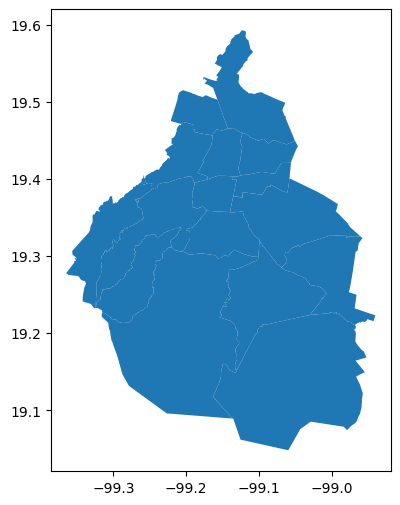

In [31]:
shape.plot(figsize=(10,6))
plt.savefig('../data/municipalities_map.pdf', format='pdf')

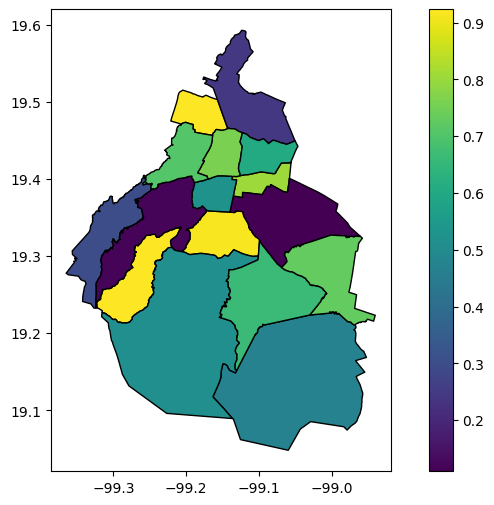

In [34]:
import numpy as np
shape['random'] = np.random.rand(len(shape))

shape.plot(column='random', figsize=(10,6), edgecolor='black', 
           legend=True)
plt.savefig('../data/municipalities_map2.pdf', format='pdf')

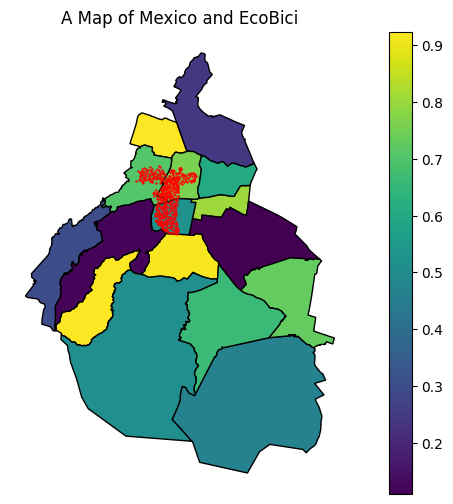

In [38]:
ax = shape.plot(column='random', figsize=(10,6), edgecolor='black', 
           legend=True)
gdf.plot(ax=ax, color="red", markersize = .5)
plt.title('A Map of Mexico and EcoBici')
plt.axis('off')
plt.savefig('../data/municipalities_map3.pdf', format='pdf')